<a href="https://colab.research.google.com/github/joaomara007/joaomara007/blob/main/C%C3%B3pia_de_Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


Upload do dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ImobPT2026.xlsx to ImobPT2026.xlsx


Este codigo e para Ler o dataset

In [ ]:
import pandas as pd

df = pd.read_excel("ImobPT2026.xlsx")

df.head()

,ID,Cidade,Preço,Area,Tipologia,Classe Energetica,URL,Partilhas X_Twitter,Interacoes Reddit,Visualizacoes YouTube,POIs Proximos,Comentário
0,00033f6d,Faro,449320,203,T6+,E,http://costa.org/,24,151,2043,"POI_61, POI_28, POI_17",Espaço muito menor do que parece nas fotos. Ce...
1,002eeb09,Faro,64695,22,T1,F,http://nogueira.org/,166,121,9749,"POI_84, POI_25",O imóvel parece ter pouca qualidade global; a ...
2,0032e8f1,Viseu,449336,127,T5,E,http://www.fernandes.com/,128,171,3395,"POI_77, POI_2, POI_24, POI_18",A casa perde pela falta de clareza: o conjunto...
3,003fed66,Porto,73180,72,T3,F,https://garcia.org/,258,296,7929,"POI_89, POI_20",Acabamentos de má qualidade em todo o lado. Ce...
4,0062e22e,Viseu,1007700,183,T5,B,https://pires.com/,142,55,5453,"POI_19, POI_70, POI_33, POI_58, POI_95",A casa convence pela naturalidade: os quartos ...


Aqui começamos à exploraração inicial usando este codigo para Ver informações gerais

In [ ]:
print(df.shape)

df.info()

(3000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ID                     3000 non-null   object
 1   Cidade                 3000 non-null   object
 2   Preço                  3000 non-null   int64 
 3   Area                   3000 non-null   int64 
 4   Tipologia              3000 non-null   object
 5   Classe Energetica      3000 non-null   object
 6   URL                    3000 non-null   object
 7   Partilhas X_Twitter    3000 non-null   int64 
 8   Interacoes Reddit      3000 non-null   int64 
 9   Visualizacoes YouTube  3000 non-null   int64 
 10  POIs Proximos          3000 non-null   object
 11  Comentário             3000 non-null   object
dtypes: int64(5), object(7)
memory usage: 281.4+ KB


Este nos permite ver as Estatísticas

In [ ]:
df.describe()

,Preço,Area,Partilhas X_Twitter,Interacoes Reddit,Visualizacoes YouTube
count,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000
mean,3.212095e+05,97.203333,248.897333,150.426333,5071.459000
std,2.857656e+05,66.039703,143.522404,87.529731,2866.290834
min,1.107100e+04,8.000000,0.000000,0.000000,53.000000
25%,1.040685e+05,39.000000,126.000000,75.000000,2610.750000
50%,2.224240e+05,84.000000,245.000000,152.000000,5108.000000
75%,4.656150e+05,148.000000,374.000000,228.000000,7599.000000
max,1.581300e+06,270.000000,500.000000,300.000000,9999.000000


Para Ver os  valores nulos

In [ ]:
df.isnull().sum()

,0
ID,0
Cidade,0
Preço,0
Area,0
Tipologia,0
Classe Energetica,0
URL,0
Partilhas X_Twitter,0
Interacoes Reddit,0
Visualizacoes YouTube,0


Aqui temos à Distribuição dos preços

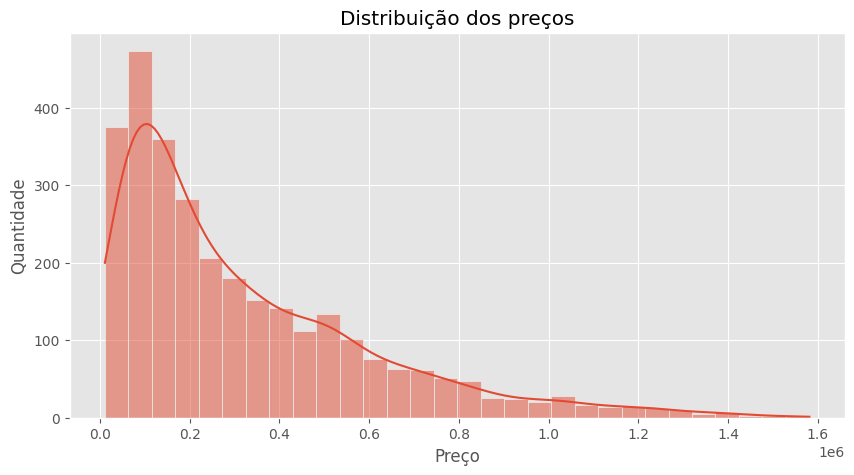

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Preço"], bins=30, kde=True)

plt.title("Distribuição dos preços")
plt.xlabel("Preço")
plt.ylabel("Quantidade")

plt.show()

Aqui vemos Casas por cidade

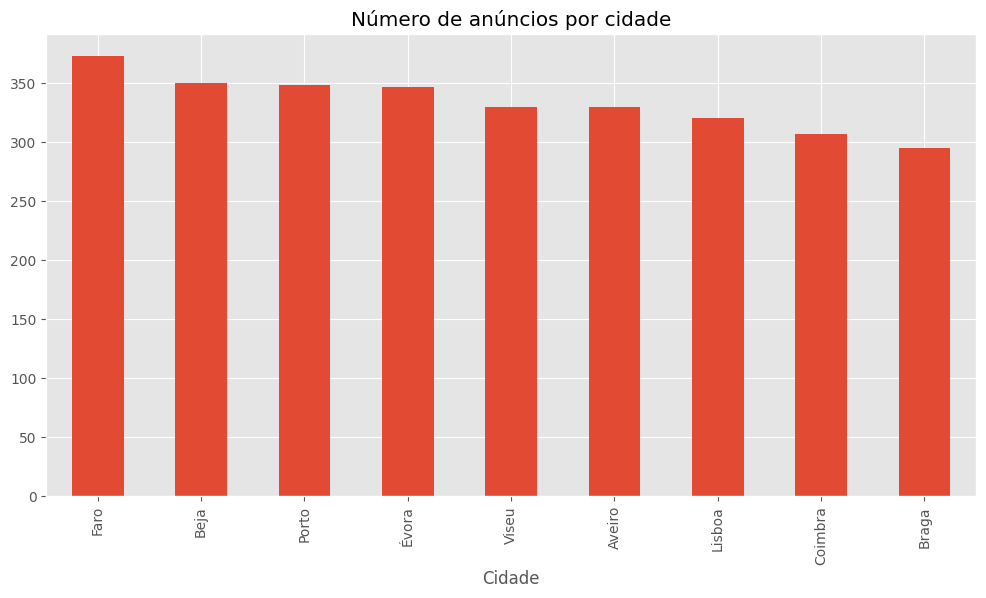

In [ ]:
plt.figure(figsize=(12,6))

df["Cidade"].value_counts().plot(kind="bar")

plt.title("Número de anúncios por cidade")

plt.show()

Relação área vs preço Observa-se uma tendência geral de aumento do preço com o aumento da área do imóvel.

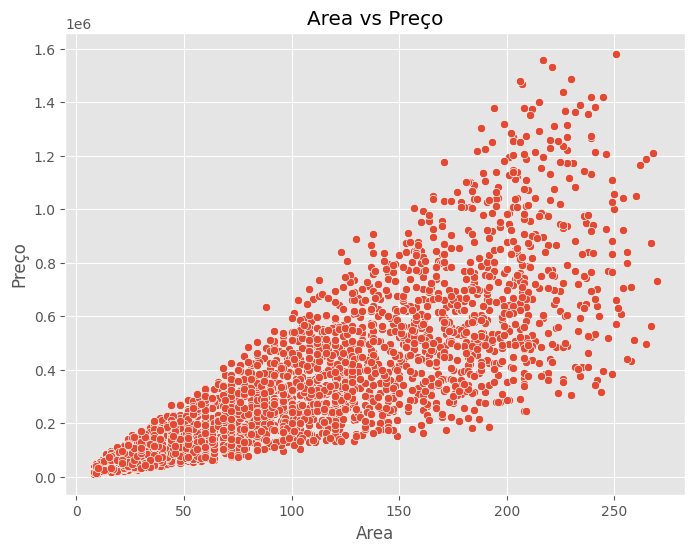

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Area", y="Preço")

plt.title("Area vs Preço")

plt.show()

Preço médio por cidade

In [ ]:
media_cidade = df.groupby("Cidade")["Preço"].mean().sort_values(ascending=False)

print(media_cidade)

Cidade
Faro       345385.882038
Coimbra    339705.000000
Aveiro     338669.000000
Braga      325659.386441
Beja       324438.348571
Lisboa     320769.184375
Viseu      302964.412121
Évora      298776.951009
Porto      295477.818966
Name: Preço, dtype: float64


Boxplot preço por tipologia

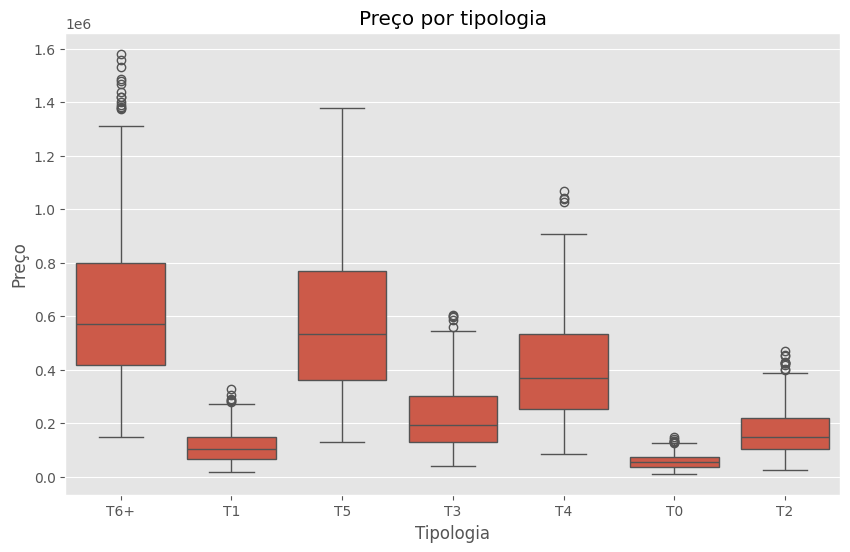

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="Tipologia", y="Preço")

plt.title("Preço por tipologia")

plt.show()

Heatmap de correlação

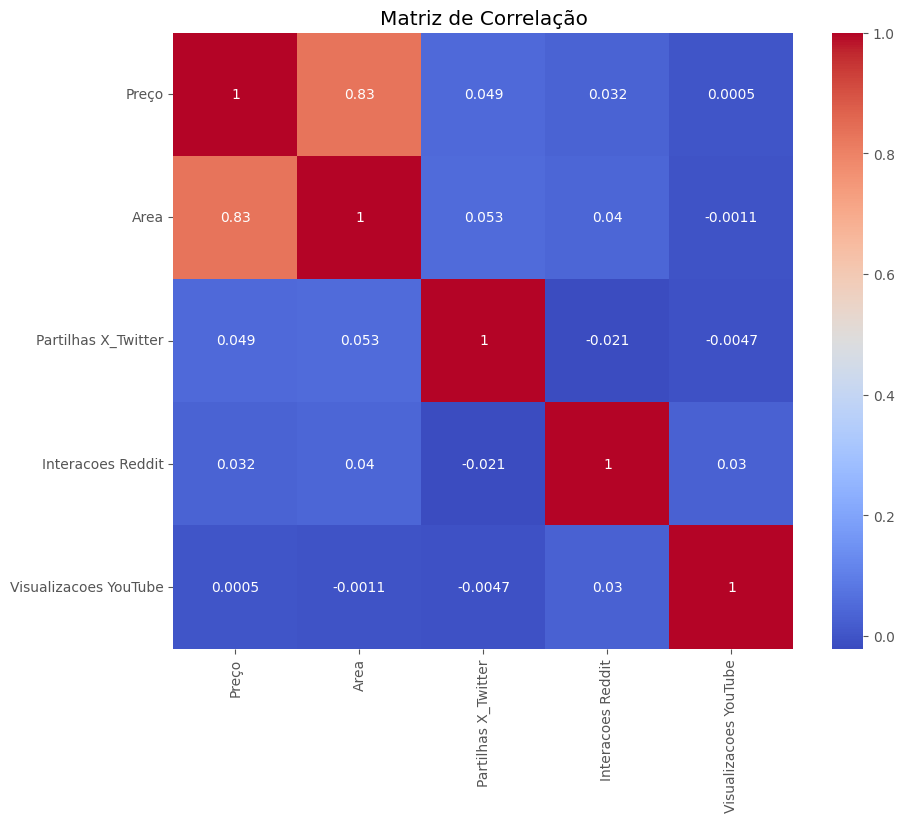

In [ ]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação")

plt.show()

Limpeza de dados

In [ ]:
df.duplicated().sum()


np.int64(0)

Ver imóveis mais caros

In [ ]:
df.sort_values(by="Preço", ascending=False).head(10)

,ID,Cidade,Preço,Area,Tipologia,Classe Energetica,URL,Partilhas X_Twitter,Interacoes Reddit,Visualizacoes YouTube,POIs Proximos,Comentário
1624,8b6e04c9,Évora,1581300,251,T6+,E,https://nogueira.pt/,231,106,2745,"POI_66, POI_52, POI_28, POI_14",A habitação tem uma base muito sólida; a ampli...
1452,7de4a42d,Braga,1559493,217,T6+,A,https://www.fernandes.com/,355,210,2712,"POI_32, POI_36, POI_1, POI_8",A proposta é forte sem precisar de exageros. O...
1374,779e7478,Lisboa,1532930,221,T6+,A+,https://castro.org/,475,194,9835,"POI_25, POI_9, POI_37, POI_69",A visita deixou-me uma impressão de casa bem r...
601,3470af30,Braga,1487419,230,T6+,C,http://anjos.pt/,124,244,7565,"POI_30, POI_78, POI_58, POI_99","O imóvel tem uma qualidade discreta, mas clara..."
2021,ac27e2ec,Porto,1480767,206,T6+,A,https://www.garcia.pt/,98,240,9923,"POI_20, POI_21, POI_23",A casa destaca-se pela coerência das soluções....
1043,5b993122,Porto,1469266,207,T6+,A,https://www.pinto.pt/,407,140,993,"POI_32, POI_63",Gostei do equilíbrio geral. A vivência diária ...
1933,a50e2b42,Porto,1438770,226,T6+,D,https://www.rodrigues.pt/,76,126,8325,"POI_5, POI_1",Gostei especialmente porque a vivência diária ...
237,16214e50,Beja,1418961,245,T6+,B-,https://www.teixeira.com/,208,271,6903,"POI_34, POI_63, POI_10, POI_12",A habitação apresenta uma atmosfera luminosa e...
1030,5a7bf83a,Beja,1417939,239,T6+,D,https://www.brito.org/,283,39,8363,"POI_62, POI_39, POI_58, POI_33",Este imóvel tem uma presença muito agradável; ...
2874,f5a19216,Porto,1400011,215,T6+,B,http://loureiro.pt/,60,248,3272,"POI_98, POI_56, POI_60, POI_59",A visita foi agradável do início ao fim. A org...


Criar preço por metro quadrado

In [ ]:
df["Preco_m2"] = df["Preço"] / df["Area"]

df.head()

,ID,Cidade,Preço,Area,Tipologia,Classe Energetica,URL,Partilhas X_Twitter,Interacoes Reddit,Visualizacoes YouTube,POIs Proximos,Comentário,Preco_m2
0,00033f6d,Faro,449320,203,T6+,E,http://costa.org/,24,151,2043,"POI_61, POI_28, POI_17",Espaço muito menor do que parece nas fotos. Ce...,2213.399015
1,002eeb09,Faro,64695,22,T1,F,http://nogueira.org/,166,121,9749,"POI_84, POI_25",O imóvel parece ter pouca qualidade global; a ...,2940.681818
2,0032e8f1,Viseu,449336,127,T5,E,http://www.fernandes.com/,128,171,3395,"POI_77, POI_2, POI_24, POI_18",A casa perde pela falta de clareza: o conjunto...,3538.078740
3,003fed66,Porto,73180,72,T3,F,https://garcia.org/,258,296,7929,"POI_89, POI_20",Acabamentos de má qualidade em todo o lado. Ce...,1016.388889
4,0062e22e,Viseu,1007700,183,T5,B,https://pires.com/,142,55,5453,"POI_19, POI_70, POI_33, POI_58, POI_95",A casa convence pela naturalidade: os quartos ...,5506.557377


Gráfico preço por m²

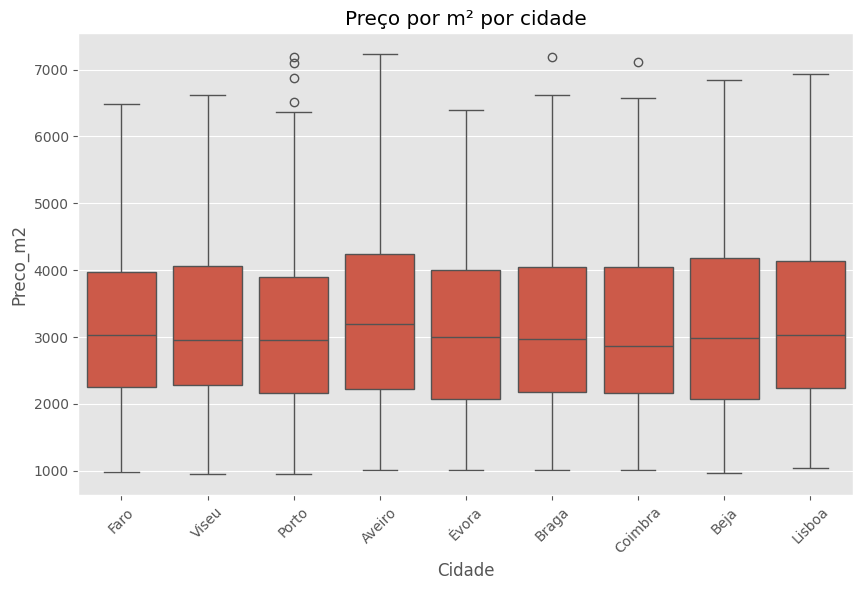

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="Cidade", y="Preco_m2")

plt.xticks(rotation=45)

plt.title("Preço por m² por cidade")

plt.show()

Cidades mais caras

In [ ]:
top_cidades = df.groupby("Cidade")["Preco_m2"].mean().sort_values(ascending=False)

print(top_cidades)

Cidade
Aveiro     3290.073601
Lisboa     3219.663523
Beja       3201.091792
Faro       3172.767999
Coimbra    3166.669640
Braga      3164.738679
Viseu      3155.377910
Porto      3129.601539
Évora      3066.234991
Name: Preco_m2, dtype: float64


Primeiro instala/importa KMeans Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Escolher variáveis

In [ ]:
X = df[["Preço", "Area", "Visualizacoes YouTube"]]

Normalizar

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Criar clusters

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

Ver clusters

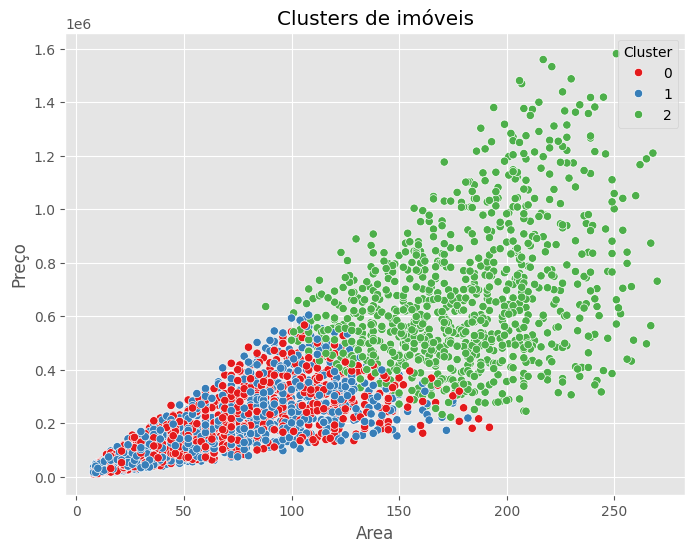

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Area",
    y="Preço",
    hue="Cluster",
    palette="Set1"
)

plt.title("Clusters de imóveis")

plt.show()

Machine Learning (prever preços)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

Features

In [ ]:
X = df[["Area", "Visualizacoes YouTube", "Interacoes Reddit"]]

y = df["Preço"]

Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Modelo

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Previsões

In [ ]:
predictions = model.predict(X_test)

Erro

In [ ]:
mae = mean_absolute_error(y_test, predictions)

print("Erro médio:", mae)

Erro médio: 108044.8040595679


Comparar preços reais vs previstos

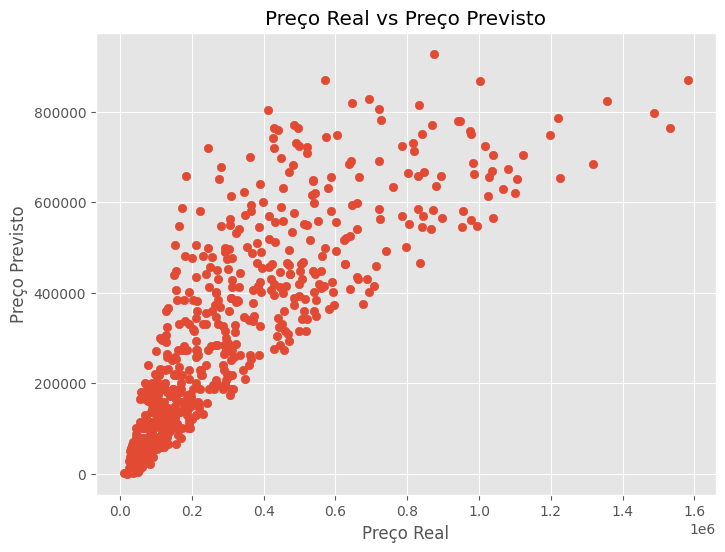

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")

plt.title("Preço Real vs Preço Previsto")

plt.show()

Importância das variáveis

In [ ]:
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": model.coef_
})

print(coeficientes)

                Variavel  Coeficiente
0                   Area  3578.316079
1  Visualizacoes YouTube     0.194013
2      Interacoes Reddit     4.880106


10 imóveis mais visualizados

In [ ]:
top_views = df.sort_values(
    by="Visualizacoes YouTube",
    ascending=False
)

top_views[[
    "Cidade",
    "Preço",
    "Area",
    "Visualizacoes YouTube"
]].head(10)

,Cidade,Preço,Area,Visualizacoes YouTube
737,Coimbra,208164,60,9999
60,Aveiro,588274,106,9997
798,Évora,125096,46,9997
354,Viseu,289737,81,9992
556,Viseu,354578,66,9988
2941,Évora,528827,199,9987
251,Aveiro,414558,135,9986
2124,Viseu,873122,267,9986
2998,Aveiro,624274,156,9982
586,Viseu,505632,92,9980


Média de preço por classe energética

In [ ]:
media_energia = df.groupby(
    "Classe Energetica"
)["Preço"].mean()

print(media_energia)

Classe Energetica
A     343034.124365
A+    360082.802532
B     316592.697548
B-    308896.959239
C     326366.049351
D     317112.197059
E     293915.555270
F     299929.220994
Name: Preço, dtype: float64


Gráfico classe energética

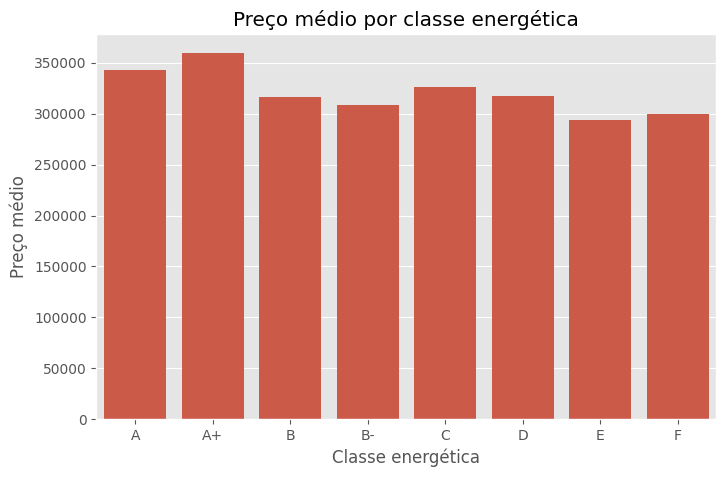

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=media_energia.index,
    y=media_energia.values
)

plt.title("Preço médio por classe energética")

plt.xlabel("Classe energética")
plt.ylabel("Preço médio")

plt.show()